# Market Analytics Case Study — Exploratory Data Analysis

**Basket:** 18 stocks across 3 sectors — Technology (Semiconductors, Software), Healthcare (Drug Manufacturers, Healthcare Plans), Financial Services (Banks, Asset Management, Credit Services).

**Period:** 2019-01-02 to present (daily OHLCV, split-adjusted via yfinance).

**Goal:** diagnose data quality, characterise volatility and return behaviour by stock/sector, identify correlation structure, and flag genuine outlier events — findings feed directly into the Week 4 case study.

## 1. Setup & Data Load

In [1]:
import sqlite3
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../visuals", exist_ok=True)
conn = sqlite3.connect("../market_data.db")

query = """
SELECT prices.*, symbols.sector, symbols.sub_sector
FROM prices
JOIN symbols ON prices.ticker = symbols.ticker
"""
df = pd.read_sql(query, conn)
df["date"] = pd.to_datetime(df["date"])

print(f"{df.shape[0]:,} rows, {df['ticker'].nunique()} tickers, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

33,820 rows, 18 tickers, 2019-01-02 to 2026-09-25


,ticker,date,open,high,low,close,volume,sector,sub_sector
0,NVDA,2019-01-02,3.231266,3.425181,3.216673,3.369282,508752000,Technology,Semiconductors
1,NVDA,2019-01-03,3.309177,3.343063,3.158299,3.165720,705552000,Technology,Semiconductors
2,NVDA,2019-01-04,3.238686,3.406630,3.208016,3.368540,585620000,Technology,Semiconductors
3,NVDA,2019-01-07,3.425676,3.583727,3.374476,3.546873,709160000,Technology,Semiconductors
4,NVDA,2019-01-08,3.628248,3.630475,3.386101,3.458572,786016000,Technology,Semiconductors


## 2. Data Quality Checks

Before drawing any conclusions, confirm the dataset is complete and free of obvious data errors.

In [2]:
# Missing values per column
df.isnull().sum()

ticker        0
date          0
open          0
high          0
low           0
close         0
volume        0
sector        0
sub_sector    0
dtype: int64

In [3]:
# Row count and price range sanity check per ticker — also cross-checks against known IPO-driven
# shorter histories for SNOW, DDOG and ALHC flagged at ingestion time
df.groupby('ticker')['close'].describe()

,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
ALHC,1382.0,13.174606,5.477578,4.470000,8.182500,12.730000,17.309999,27.270000
AMD,1944.0,126.338575,103.293060,17.049999,74.967503,101.750000,149.830006,630.630005
AXP,1944.0,187.409916,83.857767,63.396404,116.730659,157.389832,260.176376,381.781555
BIIB,1944.0,236.945643,57.017576,113.379997,199.587498,234.845001,279.252502,414.709991
BX,1944.0,92.026785,41.031359,22.046982,50.654799,93.386162,121.078278,187.206375
CRM,1944.0,213.743496,50.658650,121.971550,167.865398,209.657585,251.947853,362.581421
DDOG,1764.0,113.462225,45.293024,28.040001,87.707499,110.129997,132.615005,288.149994
JPM,1944.0,165.002019,78.318412,66.463875,105.668667,135.206680,213.854416,365.179993
KKR,1944.0,69.342531,38.619942,17.167793,37.060044,56.649326,100.751045,165.185257


In [4]:
# Minimum values — flag anything at or near $0, which would indicate a data error rather than a real price
df.groupby('ticker')[['date', 'open', 'close', 'high', 'low', 'volume']].min()

,date,open,close,high,low,volume
ticker,,,,,,
ALHC,2021-03-26,4.530000,4.470000,4.740000,4.460000,64700
AMD,2019-01-02,17.549999,17.049999,18.680000,16.940001,7956800
AXP,2019-01-02,66.687579,63.396404,69.335220,61.594517,665800
BIIB,2019-01-02,110.309998,113.379997,116.389999,110.040001,600
BX,2019-01-02,22.077151,22.046982,22.718273,21.503914,605500
CRM,2019-01-02,123.188306,121.971550,127.113363,113.130316,1238000
DDOG,2019-09-19,27.900000,28.040001,29.250000,27.549999,574800
JPM,2019-01-02,68.591632,66.463875,70.433375,64.681005,3220500
KKR,2019-01-02,17.200263,17.167793,17.874325,14.607540,771700


In [5]:
# Data completeness — confirm every ticker's history runs through the same most recent date,
# i.e. no stock is silently missing recent days
df.groupby('ticker')['date'].max().sort_values()

ticker
ALHC   2026-09-25
UNH    2026-09-25
SNOW   2026-09-25
NVS    2026-09-25
NVDA   2026-09-25
MU     2026-09-25
MOH    2026-09-25
LLY    2026-09-25
KKR    2026-09-25
JPM    2026-09-25
DDOG   2026-09-25
CRM    2026-09-25
BX     2026-09-25
BIIB   2026-09-25
AXP    2026-09-25
AMD    2026-09-25
V      2026-09-25
WFC    2026-09-25
Name: date, dtype: datetime64[us]

**Data quality — summary:** no missing values across any column. Per-ticker row counts match expectations (1,933 trading days for the long-history names; shorter for SNOW, DDOG and ALHC due to their more recent IPOs). No zero or near-zero prices. All 18 tickers carry data through the same most recent trading date — no stock is silently stale. Dataset is clean and ready for analysis.

## 3. Returns & Volatility

Daily return is calculated as `(close − previous close) / previous close` per ticker. Standard deviation of daily return — not of raw price — is the correct volatility measure, since raw price std is distorted by a stock's absolute price level rather than how much it actually moves day to day.

In [6]:
df_sorted = df.sort_values(['ticker', 'date']).copy()
df_sorted['daily_return'] = df_sorted.groupby('ticker')['close'].pct_change()

volatility = df_sorted.groupby('ticker')['daily_return'].std().sort_values(ascending=False) * 100
volatility = volatility.reset_index()
volatility.columns = ['ticker', 'volatility']

sector_lookup = df_sorted[['ticker', 'sector', 'sub_sector']].drop_duplicates()
volatility = volatility.merge(sector_lookup, on='ticker').sort_values('volatility', ascending=False)
volatility

,ticker,volatility,sector,sub_sector
0,ALHC,4.093172,Healthcare,Healthcare Plans
1,SNOW,3.912621,Technology,Software
2,DDOG,3.791456,Technology,Software
3,AMD,3.527087,Technology,Semiconductors
4,MU,3.403021,Technology,Semiconductors
5,NVDA,3.178750,Technology,Semiconductors
6,BIIB,2.780632,Healthcare,Drug Manufacturers
7,MOH,2.611532,Healthcare,Healthcare Plans
8,KKR,2.485913,Financial Services,Asset Management
9,BX,2.454730,Financial Services,Asset Management


**Finding — volatility by ticker:** Technology names (NVDA, MU, AMD, DDOG, SNOW) cluster at the top; Financial Services and the large Healthcare names (NVS, UNH, LLY) cluster at the bottom. One clear exception: **ALHC (Healthcare)** is the single most volatile stock in the entire basket — investigated below.

### Case study: why is a Healthcare stock (ALHC) the most volatile name in the basket?

In [7]:
# Market cap comparison — is ALHC's volatility explained by company size rather than sector?
tickers_list = ['ALHC', 'UNH', 'NVDA']

for t in tickers_list:
    info = yf.Ticker(t).info
    market_cap = info.get('marketCap')
    print(f"{t}: ${market_cap:,}" if market_cap else f"{t}: not available")

ALHC: $1,736,232,192
UNH: $337,782,898,688
NVDA: $5,776,928,145,408


In [8]:
# ALHC volatility by year since its 2021 IPO — testing whether volatility has settled as the company matured
alhc = df_sorted[df_sorted['ticker'] == 'ALHC'].copy()
alhc['year'] = alhc['date'].dt.year
alhc.groupby('year')['daily_return'].std() * 100

year
2021    3.866416
2022    4.331350
2023    4.113053
2024    4.440756
2025    2.967486
2026    4.755599
Name: daily_return, dtype: float64

**Finding — ALHC:** market cap is ~\$1.6B vs. ~\$334B for UNH and ~\$5.6T for NVDA — roughly 200x smaller than its own sub-sector peer. Volatility has **not** shown a clean decline since the 2021 IPO (ranging 2.97%–4.76% year to year, non-monotonic), suggesting company-specific factors beyond "newly public" status are still in play. **Conclusion: sector label is a weak predictor of volatility — market cap and maturity matter more.**

## 4. Distribution of Daily Returns

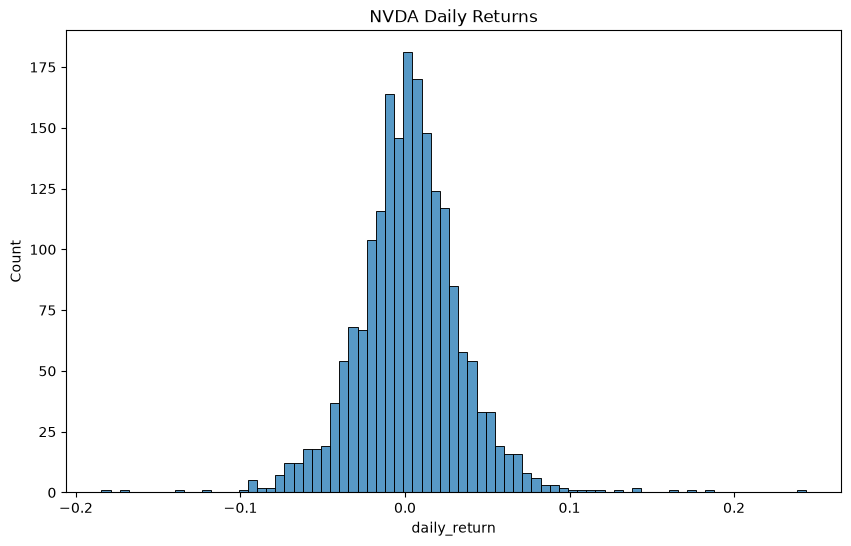

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_sorted[df_sorted['ticker'] == 'NVDA'], x='daily_return')
plt.title("NVDA Daily Returns")
plt.savefig('../visuals/nvda_daily_returns_hist.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding — NVDA returns:** distribution is centred near zero as expected for most trading days, but shows clear fat tails — several single-day moves beyond ±15%, almost certainly earnings events. Standard deviation alone understates the risk of these extreme single-day moves.

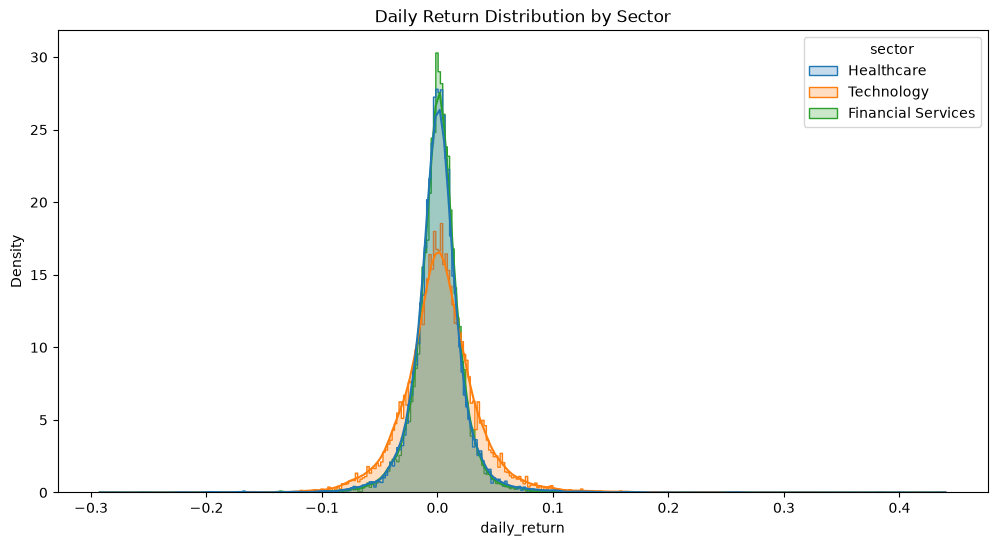

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_sorted, x='daily_return', hue='sector', kde=True, element='step', stat='density', common_norm=False)
plt.title("Daily Return Distribution by Sector")
plt.savefig('../visuals/daily_return_distribution_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding — by sector:** Technology shows a visibly flatter, wider distribution than Healthcare or Financial Services, consistent with higher day-to-day volatility. Financial Services shows the tightest, most peaked distribution, reflecting more stable, mature business models.

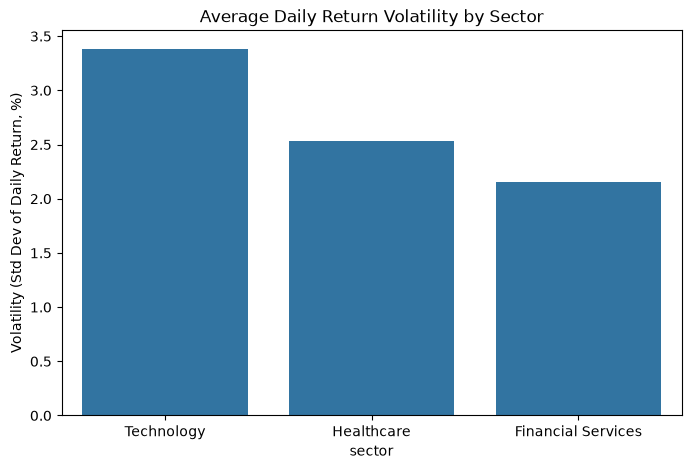

In [11]:
sector_vol = df_sorted.groupby('sector')['daily_return'].std().sort_values(ascending=False) * 100
sector_vol = sector_vol.reset_index()
sector_vol.columns = ['sector', 'volatility']

plt.figure(figsize=(8, 5))
sns.barplot(data=sector_vol, x='sector', y='volatility')
plt.title("Average Daily Return Volatility by Sector")
plt.ylabel("Volatility (Std Dev of Daily Return, %)")
plt.savefig('../visuals/sector_volatility_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding — sector volatility (aggregate):** confirms the distribution chart numerically — Technology highest, Financial Services lowest, Healthcare in between (pulled up by ALHC specifically, not the sector broadly).

## 5. Correlation Analysis

Correlation of daily returns indicates whether stocks move together (diversification risk) or independently (true diversification).

In [12]:
returns_wide = df_sorted.pivot(index='date', columns='ticker', values='daily_return')
returns_wide.head()

ticker,ALHC,AMD,AXP,BIIB,BX,CRM,DDOG,JPM,KKR,LLY,MOH,MU,NVDA,NVS,SNOW,UNH,V,WFC
date,,,,,,,,,,,,,,,,,,
2019-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,NaN,-0.094530,-0.019519,0.007581,-0.027935,-0.037993,NaN,-0.014212,-0.046381,-0.031076,-0.061919,-0.053435,-0.060417,0.008089,NaN,-0.027270,-0.036037,-0.007883
2019-01-04,NaN,0.114370,0.045060,0.036905,0.034212,0.057976,NaN,0.036866,0.068947,0.030096,0.035505,0.054839,0.064068,0.013571,NaN,0.011695,0.043081,0.029633
2019-01-07,NaN,0.082632,0.005428,0.012785,0.029772,0.030878,NaN,0.000695,0.034500,0.005407,0.073773,0.039755,0.052941,-0.011759,NaN,0.001920,0.018032,-0.006465
2019-01-08,NaN,0.008751,0.004890,0.006328,0.008673,0.024610,NaN,-0.001886,0.021267,0.009195,0.089682,-0.007647,-0.024895,0.021678,NaN,0.013370,0.005439,-0.002099


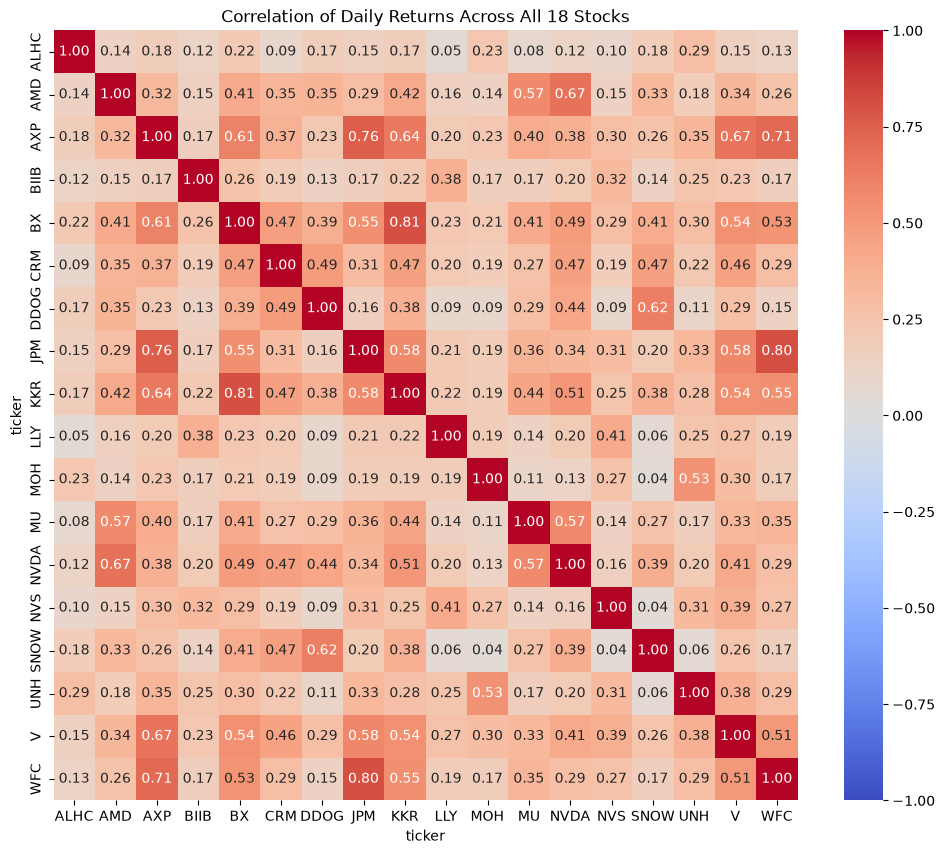

In [13]:
corr_matrix = returns_wide.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Correlation of Daily Returns Across All 18 Stocks")
plt.savefig('../visuals/correlation_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()

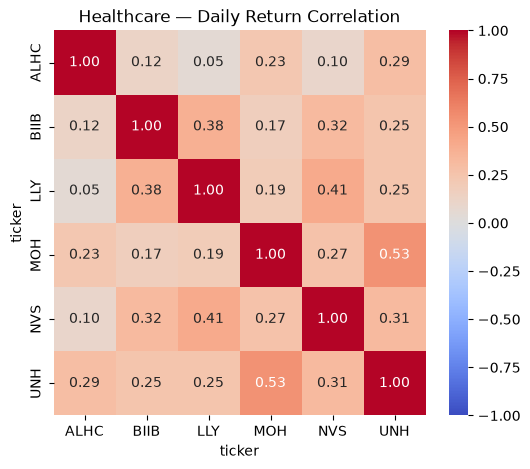

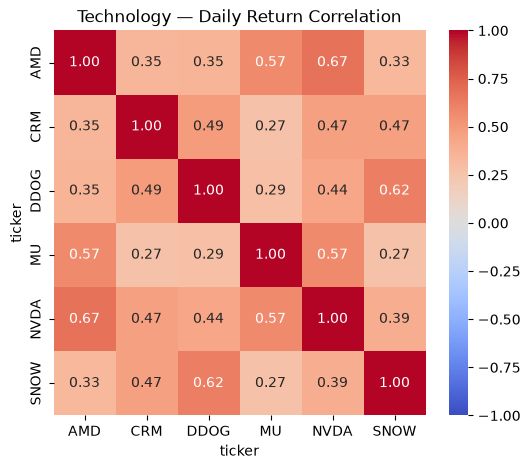

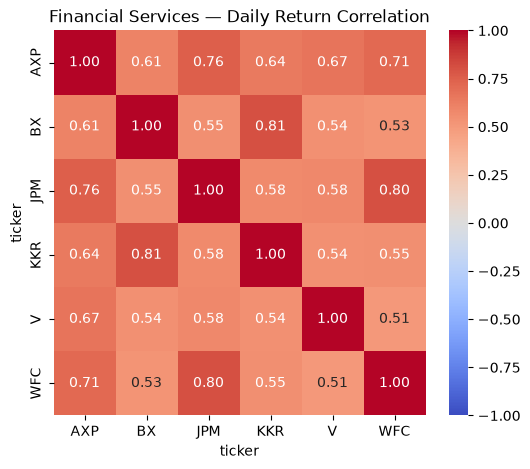

In [14]:
# Per-sector correlation — removes cross-sector noise to see within-sector structure clearly
sectors = df_sorted[['ticker', 'sector']].drop_duplicates()

for sector_name in sectors['sector'].unique():
    tickers_in_sector = sectors[sectors['sector'] == sector_name]['ticker'].tolist()
    sector_corr = returns_wide[tickers_in_sector].corr()

    plt.figure(figsize=(6, 5))
    sns.heatmap(sector_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title(f"{sector_name} — Daily Return Correlation")
    plt.savefig(f'../visuals/correlation_{sector_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

**Finding — correlation:** Financial Services shows the strongest within-sector correlation (0.5–0.8 across most pairs — JPM/WFC 0.80, BX/KKR 0.81), consistent with shared macro sensitivity (rates, consumer spending). Technology shows a moderate cluster driven mainly by the three semiconductor names (~0.57 each pair) rather than the sector as a whole. Healthcare shows almost no within-sector correlation (highest pair UNH/MOH at only 0.53) — drug manufacturers and healthcare plans are genuinely different businesses with different drivers, despite sharing a sector label. **A portfolio of only Financial Services names offers little true diversification; a Healthcare-heavy portfolio offers more.**

## 6. Outlier Detection

Two methods are compared: standard z-score (mean/std-based, threshold ±3) and modified z-score (median/MAD-based, threshold ±3.5, more resistant to a stock's own extreme values skewing its threshold).

### Standard z-score

In [15]:
df_sorted['return_mean'] = df_sorted.groupby('ticker')['daily_return'].transform('mean')
df_sorted['return_std'] = df_sorted.groupby('ticker')['daily_return'].transform('std')
df_sorted['z_score'] = (df_sorted['daily_return'] - df_sorted['return_mean']) / df_sorted['return_std']

outliers = df_sorted[df_sorted['z_score'].abs() > 3]
outliers_sorted = outliers.sort_values('z_score', key=abs, ascending=False)
outliers_sorted[['date', 'ticker', 'sector', 'daily_return', 'z_score']].head(20)

,date,ticker,sector,daily_return,z_score
15407,2020-11-04,BIIB,Healthcare,0.439739,15.806584
15884,2022-09-28,BIIB,Healthcare,0.398503,14.323616
15553,2021-06-07,BIIB,Healthcare,0.383414,13.780942
18468,2025-04-17,UNH,Healthcare,-0.223797,-10.840752
12984,2026-09-08,NVS,Healthcare,-0.139321,-10.630629
7762,2020-08-26,CRM,Technology,0.260449,10.616506
14996,2019-03-21,BIIB,Healthcare,-0.292305,-10.519948
15410,2020-11-09,BIIB,Healthcare,-0.281666,-10.137351
32184,2020-03-24,AXP,Financial Services,0.218822,10.000897
20614,2026-02-06,MOH,Healthcare,-0.255146,-9.793612


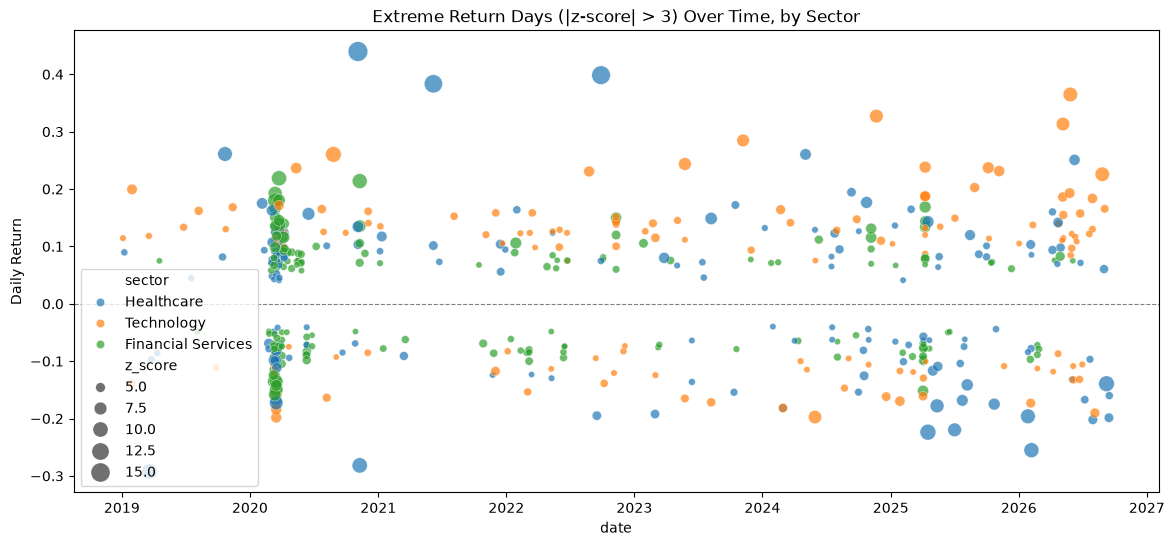

In [16]:
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=outliers, x='date', y='daily_return', hue='sector',
    size=outliers['z_score'].abs(), sizes=(20, 200), alpha=0.7
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Extreme Return Days (|z-score| > 3) Over Time, by Sector")
plt.ylabel("Daily Return")
plt.savefig('../visuals/outliers_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding — z-score outliers:** two distinct patterns. (1) **March 2020** — AXP, JPM and V all show extreme z-scores on 2020-03-13 and 2020-03-24, the COVID-19 crash — a genuine, shared market event, independently confirmed across three Financial Services names on the same dates. (2) **BIIB** appears repeatedly with the largest z-scores in the dataset (up to 15.8) — consistent with biotech's binary, event-driven nature (FDA approvals/rejections), where most days are quiet, so a rare large move produces an outsized z-score relative to the stock's own low baseline volatility.

### Modified z-score (median/MAD-based)

In [17]:
def calc_mad(series):
    return (series - series.median()).abs().median()

df_sorted['return_median'] = df_sorted.groupby('ticker')['daily_return'].transform('median')
df_sorted['return_mad'] = df_sorted.groupby('ticker')['daily_return'].transform(calc_mad)
df_sorted['modified_z'] = 0.6745 * (df_sorted['daily_return'] - df_sorted['return_median']) / df_sorted['return_mad']

outliers_modz = df_sorted[df_sorted['modified_z'].abs() > 3.5]
outliers_modz_sorted = outliers_modz.sort_values('modified_z', key=abs, ascending=False)
outliers_modz_sorted[['date', 'ticker', 'sector', 'daily_return', 'modified_z']].head(20)

,date,ticker,sector,daily_return,modified_z
15407,2020-11-04,BIIB,Healthcare,0.439739,27.772337
15884,2022-09-28,BIIB,Healthcare,0.398503,25.169596
15553,2021-06-07,BIIB,Healthcare,0.383414,24.217154
14996,2019-03-21,BIIB,Healthcare,-0.292305,-18.433078
15410,2020-11-09,BIIB,Healthcare,-0.281666,-17.761586
18468,2025-04-17,UNH,Healthcare,-0.223797,-17.209911
15145,2019-10-22,BIIB,Healthcare,0.261107,16.497353
18662,2026-01-27,UNH,Healthcare,-0.196053,-15.083711
32184,2020-03-24,AXP,Financial Services,0.218822,14.877087
7762,2020-08-26,CRM,Technology,0.260449,14.671791


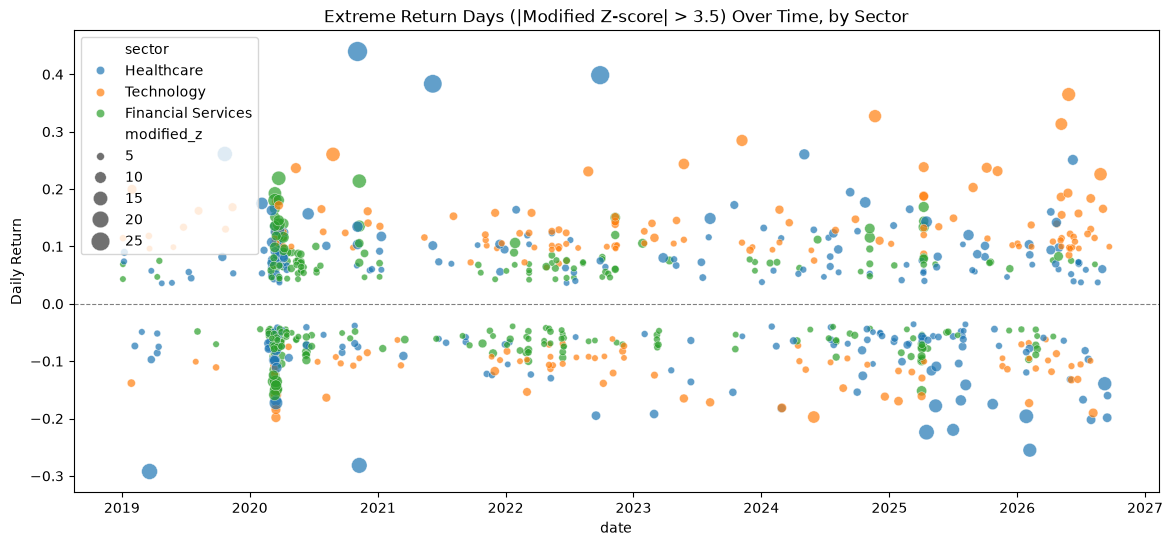

In [18]:
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=outliers_modz, x='date', y='daily_return', hue='sector',
    size=outliers_modz['modified_z'].abs(), sizes=(20, 200), alpha=0.7
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("Extreme Return Days (|Modified Z-score| > 3.5) Over Time, by Sector")
plt.ylabel("Daily Return")
plt.savefig('../visuals/outliers_modified_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding — method comparison:** the top-tier events (BIIB's single-day moves, the March 2020 crash) are identified by both methods — confirming they are genuine extreme events, not a methodology artifact. The modified z-score flags substantially more moderate outliers, since MAD is not inflated by a handful of large moves the way standard deviation is. **For the case study writeup, standard z-score (threshold 3) is used as the headline list — cleaner and more defensible — with modified z-score noted as a methodological check.**

## 7. Data Integrity Check — Stock Split Adjustment

Confirming yfinance's split-adjusted prices don't produce a false price cliff around NVDA's 10-for-1 split (10 June 2024).

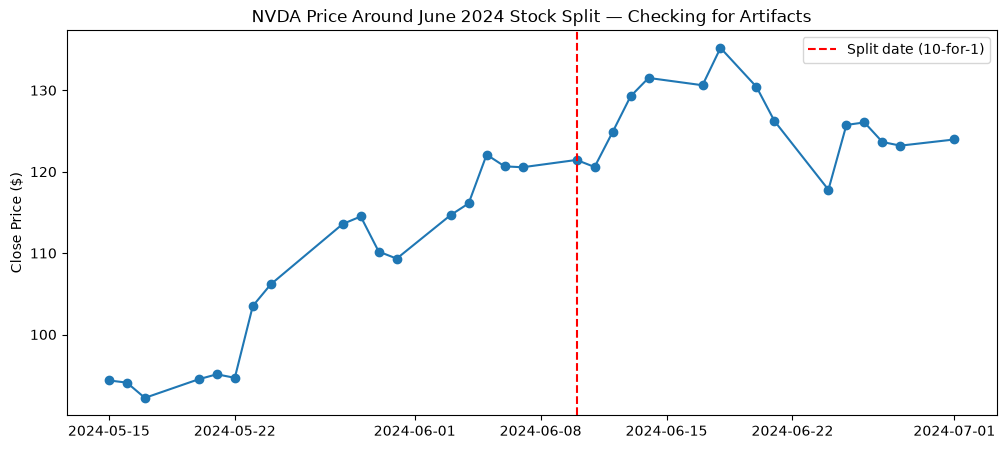

In [19]:
nvda = df_sorted[df_sorted['ticker'] == 'NVDA'].copy()
nvda_window = nvda[(nvda['date'] >= '2024-05-15') & (nvda['date'] <= '2024-07-01')]

plt.figure(figsize=(12, 5))
plt.plot(nvda_window['date'], nvda_window['close'], marker='o')
plt.axvline(pd.Timestamp('2024-06-10'), color='red', linestyle='--', label='Split date (10-for-1)')
plt.title("NVDA Price Around June 2024 Stock Split — Checking for Artifacts")
plt.ylabel("Close Price ($)")
plt.legend()
plt.savefig('../visuals/nvda_split_check.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** no discontinuity at the split date — price moves smoothly through 10 June 2024. Confirms data is correctly split-adjusted; downstream return calculations are not distorted by split artifacts.

## 8. Price Trend — Daily Close vs. 20-Day Rolling Average

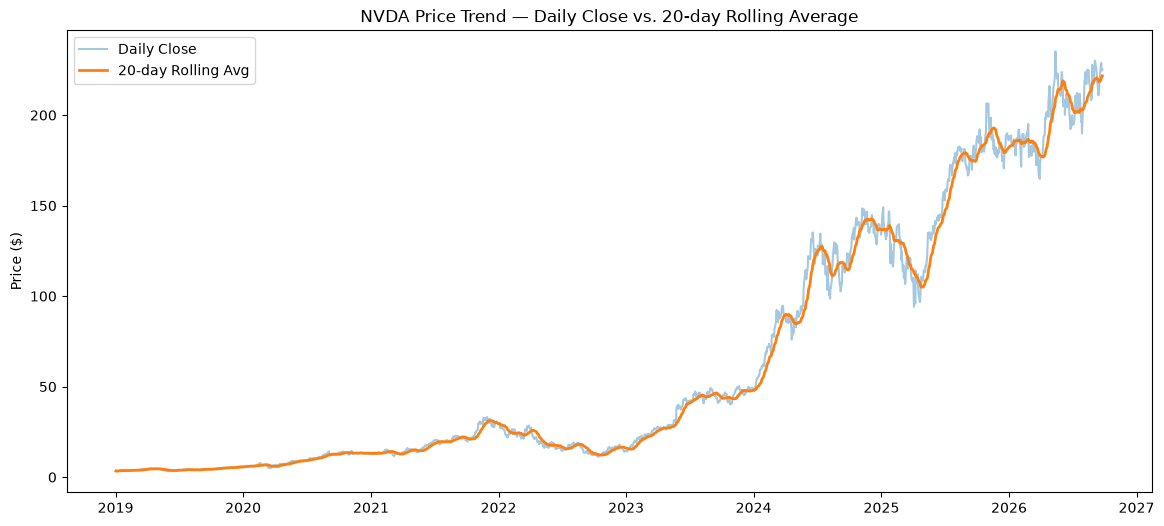

In [20]:
query = """
SELECT
    date,
    ticker,
    close,
    AVG(close) OVER (
        PARTITION BY ticker
        ORDER BY date
        ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
    ) AS rolling_20day_avg
FROM prices
WHERE ticker = 'NVDA'
ORDER BY date
"""
nvda_trend = pd.read_sql(query, conn)
nvda_trend['date'] = pd.to_datetime(nvda_trend['date'])

plt.figure(figsize=(14, 6))
plt.plot(nvda_trend['date'], nvda_trend['close'], label='Daily Close', alpha=0.4)
plt.plot(nvda_trend['date'], nvda_trend['rolling_20day_avg'], label='20-day Rolling Avg', linewidth=2)
plt.title("NVDA Price Trend — Daily Close vs. 20-day Rolling Average")
plt.ylabel("Price ($)")
plt.legend()
plt.savefig('../visuals/nvda_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** the 20-day rolling average smooths daily noise and clearly shows NVDA's underlying trend, confirming the practical value of rolling windows for trend identification over raw daily closes.

## Summary of Key Findings

1. **Technology shows the highest volatility, Financial Services the lowest**, confirmed both by distribution shape and aggregate standard deviation.
2. **Sector label is a weak predictor of volatility within Healthcare** — ALHC (~\$1.6B market cap) is the single most volatile stock in the basket despite being Healthcare, vs. ~\$334B UNH in the same sub-sector; company size/maturity matters more than sector classification.
3. **Financial Services shows strong within-sector correlation (0.5–0.8)**, reflecting shared macro sensitivity; Healthcare shows almost none, reflecting genuinely different sub-industries (drug manufacturers vs. healthcare plans) sharing one label.
4. **March 2020 produced simultaneous extreme moves across multiple Financial Services stocks** — a real, shared market event (COVID-19 crash), not noise, independently confirmed by z-score across three names.
5. **BIIB shows the most extreme single-stock outliers in the dataset**, consistent with binary, event-driven dynamics typical of biotech/drug-approval stocks.
6. **Outlier detection method matters**: standard and modified z-score agree on top-tier events, but modified z-score is substantially more sensitive to moderate outliers — standard z-score (threshold 3) is used as the headline method for its clarity.
7. Data quality checks (nulls, price minimums, split-adjustment, date completeness) confirm the dataset is clean and reliable for the Week 3–4 metrics and case study work.